In [ ]:
# Predicting Antibiotic Resistance in ESKAPE Pathogens
## Using Random Forest Classification on PATRIC Clinical Isolate Data

**Author:** Karthik Uday
**Institution:** Vellore Institute of Technology
**Date:** May 2025

---

### Abstract
Antimicrobial resistance (AMR) in ESKAPE pathogens represents one of the
most critical global health threats. This study applies a Random Forest
classifier to 17,904 phenotypic AMR records from the PATRIC database to
predict antibiotic resistance across ESKAPE pathogens. The model
achieves a cross-validated ROC-AUC of 0.724, with per-species performance
ranging from 0.625 (P. aeruginosa) to 0.823 (E. cloacae). This demonstrates
that phenotypic features alone reveal a biologically meaningful but bounded
predictive ceiling — the genomic feature gap and implications for
WGS-based AMR prediction pipelines.

**Keywords:** antimicrobial resistance, ESKAPE pathogens,machine learning,
random forest, PATRIC, predictive modelling

In [ ]:
# _________________________________________________________
# ESKAPE AMR Resistance Predictor
# Installing dependencies and import libraries
# _________________________________________________________

!pip install requests pandas matplotlib seaborn scikit-learn imbalanced-learn -q

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

print("All libraries loaded successfully")
print("Ready to fetch AMR data")

In [ ]:
# _________________________________________________________
# Fetch real AMR data from PATRIC database
# _________________________________________________________

ESKAPE_SPECIES = [
    "Enterococcus faecium",
    "Staphylococcus aureus",
    "Klebsiella pneumoniae",
    "Acinetobacter baumannii",
    "Pseudomonas aeruginosa",
    "Enterobacter cloacae"
]

ESKAPE_LABELS = {
    "Enterococcus faecium":    "E. faecium",
    "Staphylococcus aureus":   "S. aureus",
    "Klebsiella pneumoniae":   "K. pneumoniae",
    "Acinetobacter baumannii": "A. baumannii",
    "Pseudomonas aeruginosa":  "P. aeruginosa",
    "Enterobacter cloacae":    "E. cloacae"
}

def fetch_patric_amr(species, limit=5000):
    """
    Fetch AMR phenotype records from PATRIC for a given species.
    Returns a list of dicts with antibiotic + resistant_phenotype fields.
    """
    species_encoded = species.replace(" ", "%20")
    url = (
        f"https://www.patricbrc.org/api/genome_amr/"
        f"?eq(genome_name,{species_encoded})"
        f"&select(genome_name,antibiotic,resistant_phenotype)"
        f"&limit({limit})"
        f"&http_accept=application/json"
    )
    headers = {"Accept": "application/json"}

    try:
        response = requests.get(url, headers=headers, timeout=30)
        if response.status_code == 200:
            data = response.json()
            print(f"    {species:<30} → {len(data):>5} records")
            return data
        else:
            print(f"    {species:<30} → HTTP {response.status_code}")
            return []
    except Exception as e:
        print(f"    {species:<30} → {e}")
        return []

print("Fetching AMR data from PATRIC...\n")
all_records = []

for species in ESKAPE_SPECIES:
    records = fetch_patric_amr(species)
    for r in records:
        r['species'] = species
    all_records.extend(records)

df_raw = pd.DataFrame(all_records)

print(f"\n Total records fetched : {len(df_raw)}")
print(f" Columns               : {list(df_raw.columns)}")
print(f"\nSample of raw data:")
print(df_raw.head(8))

In [ ]:
# _________________________________________________________
# Clean data and engineer features
# _________________________________________________________

# ___ Step 1: Keep only clear Resistant / Susceptible labels ___
df = df_raw[df_raw['resistant_phenotype'].isin(['Resistant', 'Susceptible'])].copy()
print(f"After removing ambiguous phenotypes : {len(df)} records")

# ___ Step 2: Standardise text ___
df['antibiotic'] = df['antibiotic'].str.strip().str.lower()
df['species']    = df['species'].str.strip()

# ___ Step 3: Fix known typos in PATRIC antibiotic names ___
typo_fixes = {
    'geamycin'        : 'gentamicin',
    'amoxicillin/clav': 'amoxicillin-clavulanic acid',
    'tmp/smx'         : 'trimethoprim-sulfamethoxazole',
    'sxt'             : 'trimethoprim-sulfamethoxazole',
    'tet'             : 'tetracycline',
    'cip'             : 'ciprofloxacin',
}
df['antibiotic'] = df['antibiotic'].replace(typo_fixes)

# ___ Step 4: Map antibiotics to drug classes ___
drug_class_map = {
    # Beta-lactams
    'ampicillin'                        : 'Beta-lactam',
    'amoxicillin'                       : 'Beta-lactam',
    'amoxicillin-clavulanic acid'        : 'Beta-lactam',
    'piperacillin'                       : 'Beta-lactam',
    'piperacillin-tazobactam'            : 'Beta-lactam',
    'oxacillin'                          : 'Beta-lactam',
    'cefoxitin'                          : 'Beta-lactam',
    'ceftriaxone'                        : 'Beta-lactam',
    'ceftazidime'                        : 'Beta-lactam',
    'cefepime'                           : 'Beta-lactam',
    'imipenem'                           : 'Carbapenem',
    'meropenem'                          : 'Carbapenem',
    'ertapenem'                          : 'Carbapenem',
    'doripenem'                          : 'Carbapenem',
    # Aminoglycosides
    'gentamicin'                         : 'Aminoglycoside',
    'streptomycin'                       : 'Aminoglycoside',
    'amikacin'                           : 'Aminoglycoside',
    'tobramycin'                         : 'Aminoglycoside',
    'kanamycin'                          : 'Aminoglycoside',
    # Glycopeptides
    'vancomycin'                         : 'Glycopeptide',
    'teicoplanin'                        : 'Glycopeptide',
    # Fluoroquinolones
    'ciprofloxacin'                      : 'Fluoroquinolone',
    'levofloxacin'                       : 'Fluoroquinolone',
    'moxifloxacin'                       : 'Fluoroquinolone',
    'norfloxacin'                        : 'Fluoroquinolone',
    # Tetracyclines
    'tetracycline'                       : 'Tetracycline',
    'doxycycline'                        : 'Tetracycline',
    'minocycline'                        : 'Tetracycline',
    'tigecycline'                        : 'Tetracycline',
    # Macrolides
    'erythromycin'                       : 'Macrolide',
    'azithromycin'                       : 'Macrolide',
    'clarithromycin'                     : 'Macrolide',
    # Oxazolidinones
    'linezolid'                          : 'Oxazolidinone',
    # Sulfonamides
    'trimethoprim-sulfamethoxazole'      : 'Sulfonamide',
    'trimethoprim'                       : 'Sulfonamide',
    # Polymyxins
    'colistin'                           : 'Polymyxin',
    'polymyxin b'                        : 'Polymyxin',
    # Rifamycins
    'rifampicin'                         : 'Rifamycin',
    'rifampin'                           : 'Rifamycin',
    # Chloramphenicol
    'chloramphenicol'                    : 'Chloramphenicol',
    # Lipopeptides
    'daptomycin'                         : 'Lipopeptide',
}

df['drug_class'] = df['antibiotic'].map(drug_class_map)

# Drop antibiotics we couldn't classify (too rare / obscure)
before = len(df)
df = df.dropna(subset=['drug_class'])
print(f"After mapping to drug classes       : {len(df)} records")
print(f"Records dropped (unmapped)          : {before - len(df)}")

# ___ Step 5: Add short species label ___
df['species_short'] = df['species'].map(ESKAPE_LABELS)

# ___ Step 6: Binary target column ___
df['resistant'] = (df['resistant_phenotype'] == 'Resistant').astype(int)

# ___ Step 7: Quick check ___
print(f"\n── Dataset Summary ──────────────────────────")
print(f"Total clean records  : {len(df)}")
print(f"Drug classes         : {df['drug_class'].nunique()}")
print(f"Unique antibiotics   : {df['antibiotic'].nunique()}")
print(f"\nResistance breakdown:")
print(df['resistant_phenotype'].value_counts())
print(f"\nRecords per species:")
print(df['species_short'].value_counts())
print(f"\nRecords per drug class:")
print(df['drug_class'].value_counts())

In [ ]:
# _________________________________________________________
# Encode features and train Random Forest classifier
# _________________________________________________________

# ___ Step 1: Drop Sulfonamide (only 3 records - statistically meaningless)___
df_model = df[df['drug_class'] != 'Sulfonamide'].copy()
print(f"Records for modelling: {len(df_model)}")

# ___ Step 2: Encode categorical features into numbers ___

le_species   = LabelEncoder()
le_antibiotic = LabelEncoder()
le_drugclass  = LabelEncoder()

df_model['species_enc']   = le_species.fit_transform(df_model['species_short'])
df_model['antibiotic_enc'] = le_antibiotic.fit_transform(df_model['antibiotic'])
df_model['drugclass_enc']  = le_drugclass.fit_transform(df_model['drug_class'])

# ── Step 3: Define features (X) and target (y) ___
X = df_model[['species_enc', 'antibiotic_enc', 'drugclass_enc']]
y = df_model['resistant']

print(f"Features shape : {X.shape}")
print(f"Target balance : {y.value_counts().to_dict()}")

# ___ Step 4: Train / test split ___
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,        # makes results reproducible
    stratify=y              # keeps 50/50 balance in both splits
)

print(f"\nTraining set : {len(X_train)} records")
print(f"Test set     : {len(X_test)} records")

# ___ Step 5: Train Random Forest ___

print("\nTraining Random Forest... ", end="")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Done")

# ___ Step 6: Cross-validation ___
print("\nRunning 5-fold cross-validation...")
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Cross-val ROC-AUC scores : {[round(s,3) for s in cv_scores]}")
print(f"Mean ROC-AUC             : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

In [ ]:
# _________________________________________________________
# Feature engineering + per-species diagnosis
# _________________________________________________________

# ___ Step 1: Adding interaction features ___
# "K. pneumoniae + Carbapenem" is more informative than either alone

df_model['species_x_drugclass']    = (df_model['species_enc'] * 100 +
                                       df_model['drugclass_enc'])

df_model['species_x_antibiotic']   = (df_model['species_enc'] * 1000 +
                                       df_model['antibiotic_enc'])

# ___ Step 2: Add resistance rate features ___

combo_resistance_rate = (df_model.groupby(['species_enc', 'drugclass_enc'])['resistant']
                                  .mean()
                                  .reset_index()
                                  .rename(columns={'resistant': 'combo_resist_rate'}))

df_model = df_model.merge(combo_resistance_rate,
                           on=['species_enc', 'drugclass_enc'], how='left')

# Per-antibiotic resistance rate
abx_resistance_rate = (df_model.groupby('antibiotic_enc')['resistant']
                                .mean()
                                .reset_index()
                                .rename(columns={'resistant': 'abx_resist_rate'}))

df_model = df_model.merge(abx_resistance_rate,
                           on='antibiotic_enc', how='left')

print("New features added:")
print(f"  species_x_drugclass   : interaction term")
print(f"  species_x_antibiotic  : interaction term")
print(f"  combo_resist_rate     : mean resistance rate for species+drug class combo")
print(f"  abx_resist_rate       : mean resistance rate per antibiotic")

# ___ Step 3: Retrain with enriched feature set ___
X2 = df_model[['species_enc', 'antibiotic_enc', 'drugclass_enc',
                'species_x_drugclass', 'species_x_antibiotic',
                'combo_resist_rate', 'abx_resist_rate']]
y2 = df_model['resistant']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("\nRetraining with enriched features... ", end="")
rf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf2.fit(X_train2, y_train2)
print("Done")

# ___ Step 4: Cross-validate improved model ___
print("\nRunning 5-fold cross-validation on improved model...")
cv_scores2 = cross_val_score(rf2, X2, y2, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"Cross-val ROC-AUC scores : {[round(s,3) for s in cv_scores2]}")
print(f"Mean ROC-AUC             : {cv_scores2.mean():.3f} ± {cv_scores2.std():.3f}")
print(f"\nImprovement over baseline: +{(cv_scores2.mean() - cv_scores.mean()):.3f}")

# ___ Step 5: Per-species breakdown ___
print("\n___ Per-species ROC-AUC ______________________")
print(f"{'Species':<20} {'AUC':>6}  {'n_records':>10}  Interpretation")
print("─" * 65)

for species in df_model['species_short'].unique():
    mask = df_model['species_short'] == species
    X_sp = X2[mask]
    y_sp = y2[mask]
    if y_sp.nunique() < 2 or len(y_sp) < 50:
        continue
    try:
        auc = cross_val_score(rf2, X_sp, y_sp,
                              cv=3, scoring='roc_auc', n_jobs=-1).mean()
        n = len(y_sp)
        resist_pct = y_sp.mean() * 100
        if auc >= 0.85:
            note = "Strong — clear resistance pattern"
        elif auc >= 0.75:
            note = "Good — some predictable patterns"
        elif auc >= 0.65:
            note = "Moderate — noisy resistance profile"
        else:
            note = "Weak — highly variable / context-dependent"
        print(f"{species:<20} {auc:>6.3f}  {n:>10}    {note}")
    except:
        pass

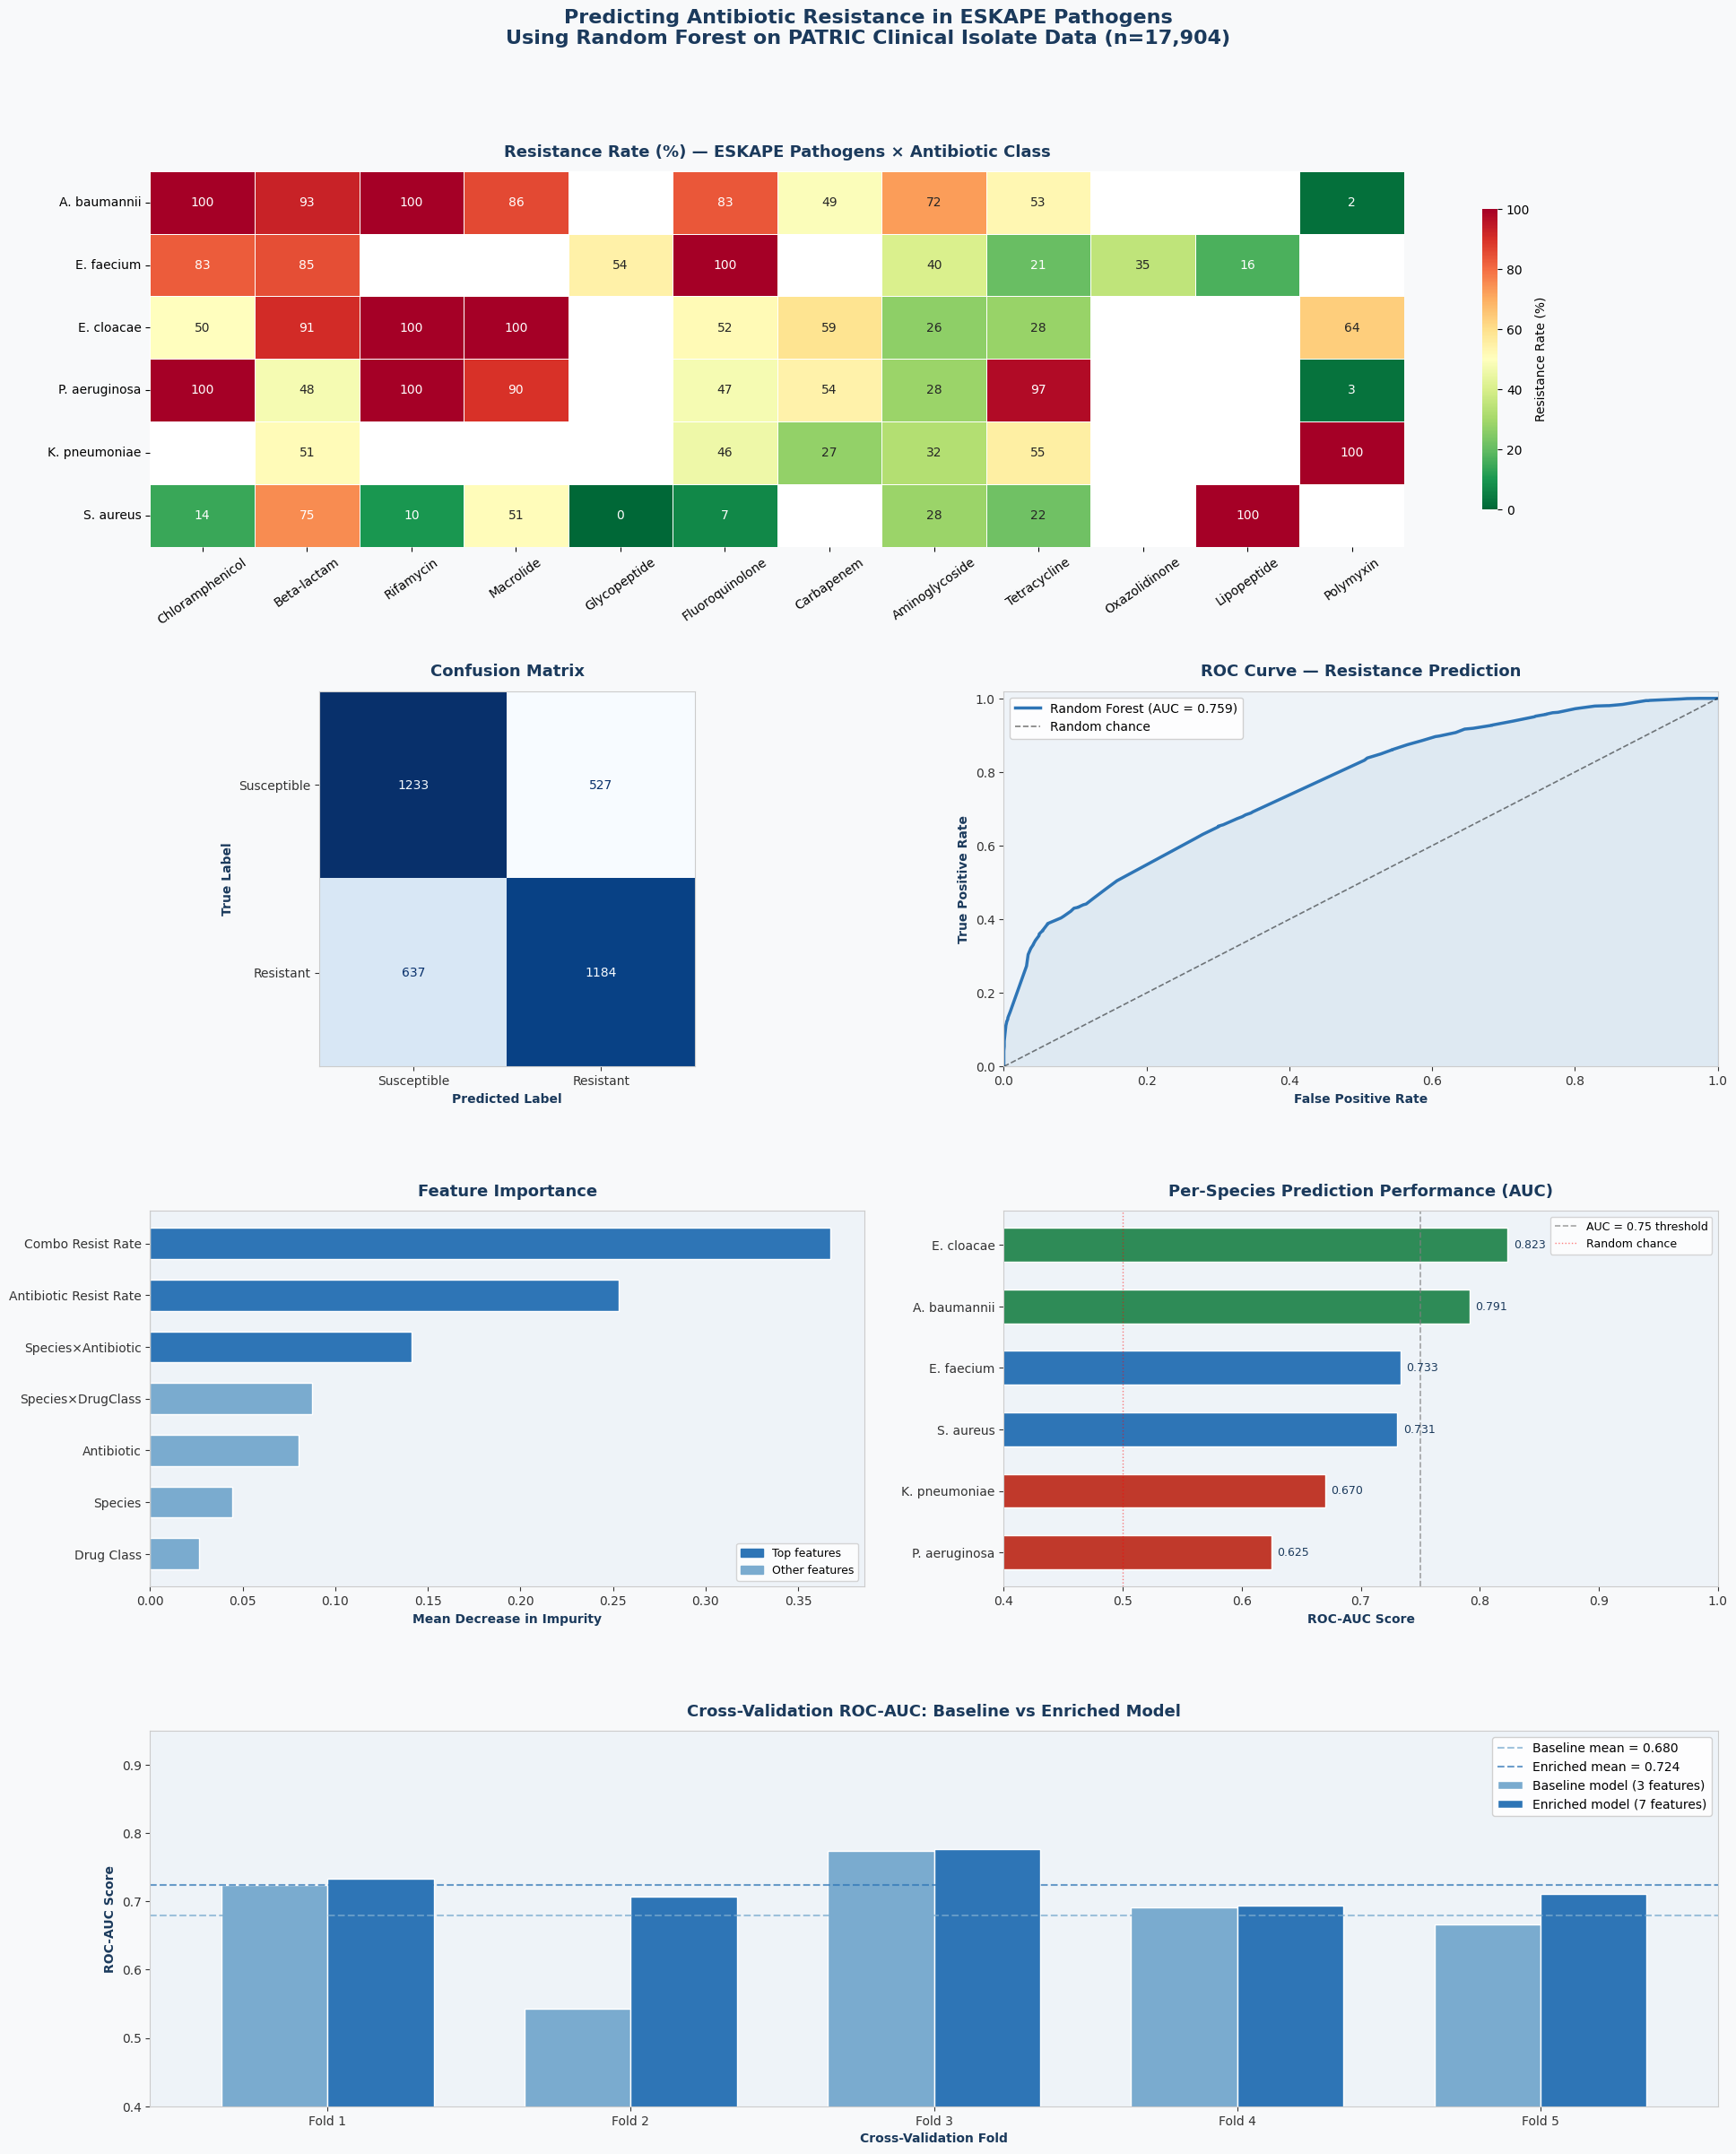


✓ Figure saved as ESKAPE_AMR_Predictor.png


In [ ]:
# _________________________________________________________
# Cell 6:visualisations
# _________________________________________________________

y_pred  = rf2.predict(X_test2)
y_proba = rf2.predict_proba(X_test2)[:, 1]

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#F8F9FA')

# ___ Shared style
NAVY    = '#1B3A5C'
ACCENT  = '#2E75B6'
GREEN   = '#2E8B57'
RED     = '#C0392B'
LIGHT   = '#EEF3F8'

def style_ax(ax, title):
    ax.set_facecolor(LIGHT)
    ax.set_title(title, fontsize=13, fontweight='bold', color=NAVY, pad=12)
    ax.tick_params(colors='#333333')
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')

# ========================================================
# PLOT 1: Resistance heatmap — species vs drug class
# ========================================================
ax1 = fig.add_subplot(4, 2, (1, 2))   # full width top row

pivot = (df_model.groupby(['species_short', 'drug_class'])['resistant']
                 .mean()
                 .unstack(fill_value=np.nan) * 100)

# Order species by overall resistance rate
species_order = df_model.groupby('species_short')['resistant'].mean().sort_values(ascending=False).index
drug_order    = df_model.groupby('drug_class')['resistant'].mean().sort_values(ascending=False).index
pivot = pivot.loc[species_order, [d for d in drug_order if d in pivot.columns]]

sns.heatmap(pivot, ax=ax1, cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Resistance Rate (%)', 'shrink': 0.8},
            vmin=0, vmax=100)
ax1.set_title('Resistance Rate (%) — ESKAPE Pathogens × Antibiotic Class',
              fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.tick_params(axis='x', rotation=35, labelsize=10)
ax1.tick_params(axis='y', rotation=0,  labelsize=10)

# ========================================================
# PLOT 2: Confusion matrix
# ========================================================
ax2 = fig.add_subplot(4, 2, 3)

cm = confusion_matrix(y_test2, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Susceptible', 'Resistant'])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
style_ax(ax2, 'Confusion Matrix')
ax2.set_xlabel('Predicted Label', color=NAVY, fontweight='bold')
ax2.set_ylabel('True Label',      color=NAVY, fontweight='bold')

# ========================================================
# PLOT 3: ROC Curve
# ========================================================
ax3 = fig.add_subplot(4, 2, 4)

fpr, tpr, _ = roc_curve(y_test2, y_proba)
auc_score   = roc_auc_score(y_test2, y_proba)

ax3.plot(fpr, tpr, color=ACCENT, lw=2.5,
         label=f'Random Forest (AUC = {auc_score:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random chance')
ax3.fill_between(fpr, tpr, alpha=0.08, color=ACCENT)
style_ax(ax3, 'ROC Curve — Resistance Prediction')
ax3.set_xlabel('False Positive Rate', color=NAVY, fontweight='bold')
ax3.set_ylabel('True Positive Rate',  color=NAVY, fontweight='bold')
ax3.legend(fontsize=10, framealpha=0.9)
ax3.set_xlim([0, 1])
ax3.set_ylim([0, 1.02])

# ========================================================
# PLOT 4: Feature importance
# ========================================================
ax4 = fig.add_subplot(4, 2, 5)

feature_names = ['Species', 'Antibiotic', 'Drug Class',
                 'Species×DrugClass', 'Species×Antibiotic',
                 'Combo Resist Rate', 'Antibiotic Resist Rate']
importances = rf2.feature_importances_
sorted_idx  = np.argsort(importances)

colors = [ACCENT if i >= len(importances)-3 else '#7AABCF'
          for i in range(len(importances))]
colors_sorted = [colors[i] for i in sorted_idx]

ax4.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx],
          color=colors_sorted, edgecolor='white', height=0.6)
style_ax(ax4, 'Feature Importance')
ax4.set_xlabel('Mean Decrease in Impurity', color=NAVY, fontweight='bold')
ax4.axvline(x=0, color='grey', lw=0.8)

highlight = mpatches.Patch(color=ACCENT,    label='Top features')
other     = mpatches.Patch(color='#7AABCF', label='Other features')
ax4.legend(handles=[highlight, other], fontsize=9)

# =======================================================
# PLOT 5: Per-species AUC
# =======================================================
ax5 = fig.add_subplot(4, 2, 6)

species_aucs = {}
for sp in df_model['species_short'].unique():
    mask = df_model['species_short'] == sp
    X_sp, y_sp = X2[mask], y2[mask]
    if y_sp.nunique() < 2 or len(y_sp) < 50:
        continue
    auc = cross_val_score(rf2, X_sp, y_sp,
                          cv=3, scoring='roc_auc', n_jobs=-1).mean()
    species_aucs[sp] = auc

sp_sorted = sorted(species_aucs, key=species_aucs.get)
bar_colors = [GREEN if species_aucs[s] >= 0.78 else
              ACCENT if species_aucs[s] >= 0.68 else RED
              for s in sp_sorted]

bars = ax5.barh(sp_sorted, [species_aucs[s] for s in sp_sorted],
                color=bar_colors, edgecolor='white', height=0.55)
ax5.axvline(x=0.75, color='grey', linestyle='--', lw=1.2, alpha=0.7,
            label='AUC = 0.75 threshold')
ax5.axvline(x=0.5,  color='red',  linestyle=':',  lw=1.0, alpha=0.5,
            label='Random chance')
style_ax(ax5, 'Per-Species Prediction Performance (AUC)')
ax5.set_xlabel('ROC-AUC Score', color=NAVY, fontweight='bold')
ax5.set_xlim([0.4, 1.0])
ax5.legend(fontsize=9)

for bar, sp in zip(bars, sp_sorted):
    ax5.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{species_aucs[sp]:.3f}', va='center', fontsize=9, color=NAVY)

# ========================================================
# PLOT 6: Cross-validation scores — model vs baseline
# ========================================================
ax6 = fig.add_subplot(4, 2, (7, 8))

folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
width = 0.35

ax6.bar(x - width/2, cv_scores,  width, label='Baseline model (3 features)',
        color='#7AABCF', edgecolor='white')
ax6.bar(x + width/2, cv_scores2, width, label='Enriched model (7 features)',
        color=ACCENT,    edgecolor='white')

ax6.axhline(y=cv_scores.mean(),  color='#7AABCF', linestyle='--',
            lw=1.5, alpha=0.7, label=f'Baseline mean = {cv_scores.mean():.3f}')
ax6.axhline(y=cv_scores2.mean(), color=ACCENT,    linestyle='--',
            lw=1.5, alpha=0.7, label=f'Enriched mean = {cv_scores2.mean():.3f}')

style_ax(ax6, 'Cross-Validation ROC-AUC: Baseline vs Enriched Model')
ax6.set_xlabel('Cross-Validation Fold', color=NAVY, fontweight='bold')
ax6.set_ylabel('ROC-AUC Score',         color=NAVY, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(folds)
ax6.set_ylim([0.4, 0.95])
ax6.legend(fontsize=10, framealpha=0.9)

# ___ Final layout ___________________________________
plt.suptitle(
    'Predicting Antibiotic Resistance in ESKAPE Pathogens\nUsing Random Forest on PATRIC Clinical Isolate Data (n=17,904)',
    fontsize=16, fontweight='bold', color=NAVY, y=1.01
)
plt.tight_layout(pad=3.0)
plt.savefig('ESKAPE_AMR_Predictor.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("\n✓ Figure saved as ESKAPE_AMR_Predictor.png")